In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


project_root = Path.cwd().parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "vic_demand_2024-07_to_2026-06.parquet"
)

df = pd.read_parquet(data_path)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,VIC1,2024-07-01 00:05:00,5404.13,281.32,TRADE
1,VIC1,2024-07-01 00:10:00,5346.60,275.61,TRADE
2,VIC1,2024-07-01 00:15:00,5240.84,270.98,TRADE
3,VIC1,2024-07-01 00:20:00,5239.06,270.98,TRADE
4,VIC1,2024-07-01 00:25:00,5226.10,270.98,TRADE


In [2]:
df["year"] = df["SETTLEMENTDATE"].dt.year
df["month"] = df["SETTLEMENTDATE"].dt.month
df["month_name"] = df["SETTLEMENTDATE"].dt.month_name()
df["day_of_week"] = df["SETTLEMENTDATE"].dt.day_name()
df["day_number"] = df["SETTLEMENTDATE"].dt.dayofweek
df["hour"] = df["SETTLEMENTDATE"].dt.hour
df["minute"] = df["SETTLEMENTDATE"].dt.minute
df["minute_of_day"] = df["hour"] * 60 + df["minute"]
df["is_weekend"] = df["day_number"] >= 5

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE,year,month,month_name,day_of_week,day_number,hour,minute,minute_of_day,is_weekend
0,VIC1,2024-07-01 00:05:00,5404.13,281.32,TRADE,2024,7,July,Monday,0,0,5,5,False
1,VIC1,2024-07-01 00:10:00,5346.60,275.61,TRADE,2024,7,July,Monday,0,0,10,10,False
2,VIC1,2024-07-01 00:15:00,5240.84,270.98,TRADE,2024,7,July,Monday,0,0,15,15,False
3,VIC1,2024-07-01 00:20:00,5239.06,270.98,TRADE,2024,7,July,Monday,0,0,20,20,False
4,VIC1,2024-07-01 00:25:00,5226.10,270.98,TRADE,2024,7,July,Monday,0,0,25,25,False


In [3]:
monthly_summary = (
    df.assign(
        year_month=df["SETTLEMENTDATE"].dt.to_period("M")
    )
    .groupby("year_month", as_index=False)
    .agg(
        mean_demand=("TOTALDEMAND", "mean"),
        minimum_demand=("TOTALDEMAND", "min"),
        peak_demand=("TOTALDEMAND", "max"),
    )
)

monthly_summary

,year_month,mean_demand,minimum_demand,peak_demand
0,2024-07,5918.824419,3455.85,8370.47
1,2024-08,5005.162825,2149.28,8241.39
2,2024-09,4651.139184,1675.21,7182.96
3,2024-10,4139.206980,1602.31,6585.04
4,2024-11,4242.131009,1491.13,7749.07
5,2024-12,4104.235793,1509.69,9887.28
6,2025-01,4408.237614,1400.13,8733.41
7,2025-02,4829.720042,2172.32,9490.53
8,2025-03,4683.500184,1930.55,8508.96
9,2025-04,4456.746509,1987.45,6428.43


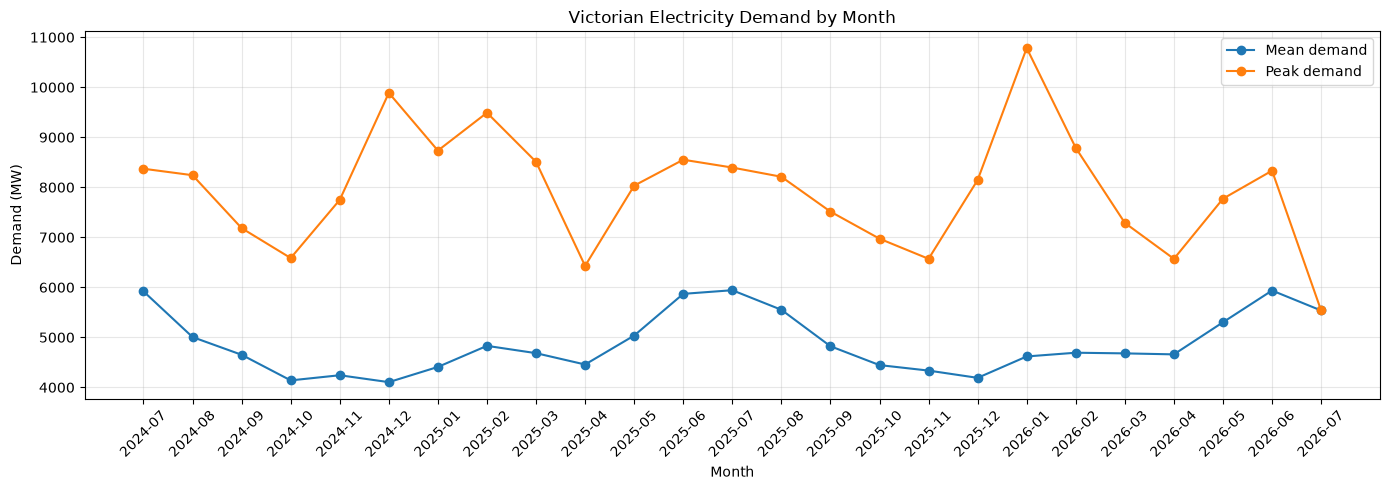

In [4]:
plot_monthly = monthly_summary.copy()
plot_monthly["year_month"] = plot_monthly["year_month"].astype(str)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_monthly["year_month"],
    plot_monthly["mean_demand"],
    marker="o",
    label="Mean demand",
)

plt.plot(
    plot_monthly["year_month"],
    plot_monthly["peak_demand"],
    marker="o",
    label="Peak demand",
)

plt.title("Victorian Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand (MW)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def get_season(month: int) -> str:
    if month in [12, 1, 2]:
        return "Summer"
    if month in [3, 4, 5]:
        return "Autumn"
    if month in [6, 7, 8]:
        return "Winter"
    return "Spring"


df["season"] = df["month"].apply(get_season)

df["season"].value_counts()

season
Winter    52992
Autumn    52992
Spring    52416
Summer    51840
Name: count, dtype: int64

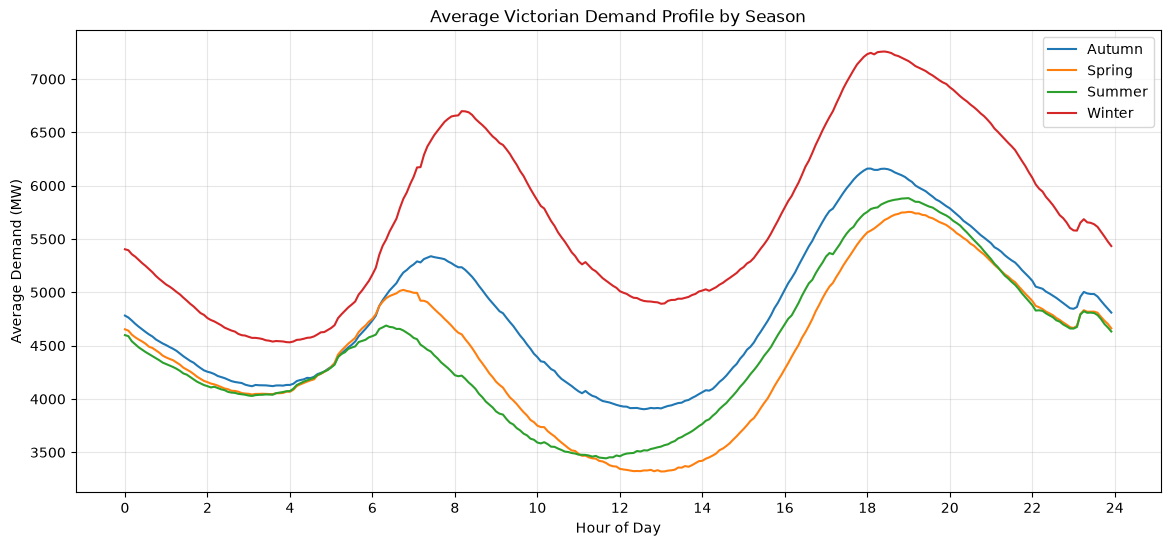

In [6]:
seasonal_profile = (
    df.groupby(
        ["season", "minute_of_day"],
        as_index=False,
    )
    ["TOTALDEMAND"]
    .mean()
)

plt.figure(figsize=(14, 6))

for season, group in seasonal_profile.groupby("season"):
    plt.plot(
        group["minute_of_day"] / 60,
        group["TOTALDEMAND"],
        label=season,
    )

plt.title("Average Victorian Demand Profile by Season")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
lag_intervals = {
    "5 minutes": 1,
    "30 minutes": 6,
    "1 hour": 12,
    "1 day": 288,
    "2 days": 576,
    "1 week": 2016,
}

lag_correlations = {}

for name, lag in lag_intervals.items():
    lag_correlations[name] = df["TOTALDEMAND"].corr(
        df["TOTALDEMAND"].shift(lag)
    )

pd.Series(
    lag_correlations,
    name="Correlation with current demand",
).sort_values(ascending=False)

5 minutes     0.998543
30 minutes    0.980704
1 hour        0.934806
1 day         0.782922
1 week        0.696155
2 days        0.657280
Name: Correlation with current demand, dtype: float64

In [8]:
train = df[
    df["SETTLEMENTDATE"] < "2026-03-01"
].copy()

validation = df[
    (df["SETTLEMENTDATE"] >= "2026-03-01")
    & (df["SETTLEMENTDATE"] < "2026-05-01")
].copy()

test = df[
    df["SETTLEMENTDATE"] >= "2026-05-01"
].copy()

print(
    f"Train:      {len(train):>7,} rows | "
    f"{train['SETTLEMENTDATE'].min()} → "
    f"{train['SETTLEMENTDATE'].max()}"
)

print(
    f"Validation: {len(validation):>7,} rows | "
    f"{validation['SETTLEMENTDATE'].min()} → "
    f"{validation['SETTLEMENTDATE'].max()}"
)

print(
    f"Test:       {len(test):>7,} rows | "
    f"{test['SETTLEMENTDATE'].min()} → "
    f"{test['SETTLEMENTDATE'].max()}"
)

Train:      175,103 rows | 2024-07-01 00:05:00 → 2026-02-28 23:55:00
Validation:  17,568 rows | 2026-03-01 00:00:00 → 2026-04-30 23:55:00
Test:        17,569 rows | 2026-05-01 00:00:00 → 2026-07-01 00:00:00


## Modelling strategy

Because electricity demand is a time series, observations are split
chronologically rather than randomly.

The training period contains observations from July 2024 through February
2026. March and April 2026 are reserved for model development and
validation, while May and June 2026 form a final holdout test period.

The test set will remain unused during model selection. This preserves a
realistic estimate of how the final forecasting system performs on unseen
future observations.

In [9]:
analysis_df = df[
    df["SETTLEMENTDATE"] < pd.Timestamp("2026-07-01")
].copy()

print(f"Original rows: {len(df):,}")
print(f"Analysis rows: {len(analysis_df):,}")
print(
    analysis_df["SETTLEMENTDATE"].min(),
    "→",
    analysis_df["SETTLEMENTDATE"].max(),
)

Original rows: 210,240
Analysis rows: 210,239
2024-07-01 00:05:00 → 2026-06-30 23:55:00


## Forecasting objective

The initial modelling task forecasts Victorian operational electricity demand
30 minutes ahead.

A 30-minute horizon is long enough to require meaningful forecasting while
remaining relevant to short-term electricity-system operations.

All model features must use only information that would have been available
at the time the forecast was issued. This avoids look-ahead bias.